In [ ]:
## 4. Growth Rate

Growth Rate measures the percentage change in new COVID-19 cases 
compared with the previous day.

Formula:

Growth Rate = ((Current Cases - Previous Cases) / Previous Cases) × 100

This indicator helps identify periods of rapid increase or decrease 
in disease transmission.

In [1]:
import pandas as pd

In [4]:
df = pd.read_csv(r"C:\Profile\Data\cleaned_covid_data.csv")

In [5]:
df.head()

,Date_reported,Country,WHO_region,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths,Case Fatality Rate
0,2020-01-05,Armenia,EURO,NaN,0,NaN,0,NaN
1,2020-01-12,Armenia,EURO,NaN,0,NaN,0,NaN
2,2020-01-19,Armenia,EURO,NaN,0,NaN,0,NaN
3,2020-01-26,Armenia,EURO,NaN,0,NaN,0,NaN
4,2020-02-02,Armenia,EURO,NaN,0,NaN,0,NaN


In [6]:
['Country', 'Date_reported']

['Country', 'Date_reported']

In [7]:
df.columns.tolist()

['Date_reported',
 'Country',
 'WHO_region',
 'New_cases',
 'Cumulative_cases',
 'New_deaths',
 'Cumulative_deaths',
 'Case Fatality Rate']

In [8]:
df = df.sort_values(['Country', 'Date_reported'])

In [10]:
df['growth_rate'] = (
    df.groupby('Country')['New_cases']
    .pct_change(fill_method=None)
) * 100

In [ ]:
## 5. 7-Day Moving Average

The 7-day moving average smooths daily fluctuations in COVID-19 cases,
making epidemic trends easier to identify.

This indicator is widely used in public health surveillance.

In [11]:
df['7_day_average'] = (
    df.groupby('Country')['New_cases']
    .transform(lambda x: x.rolling(window=7).mean())
)

In [12]:
df[['Country', 'Date_reported', 'New_cases', '7_day_average']].head(15)

,Country,Date_reported,New_cases,7_day_average
15,Afghanistan,2020-01-05,NaN,NaN
16,Afghanistan,2020-01-12,NaN,NaN
17,Afghanistan,2020-01-19,NaN,NaN
18,Afghanistan,2020-01-26,NaN,NaN
19,Afghanistan,2020-02-02,NaN,NaN
20,Afghanistan,2020-02-09,NaN,NaN
21,Afghanistan,2020-02-16,NaN,NaN
22,Afghanistan,2020-02-23,NaN,NaN
23,Afghanistan,2020-03-01,1.0,NaN
24,Afghanistan,2020-03-08,NaN,NaN


In [13]:
country_data = df[df['Country'] == 'Nigeria']

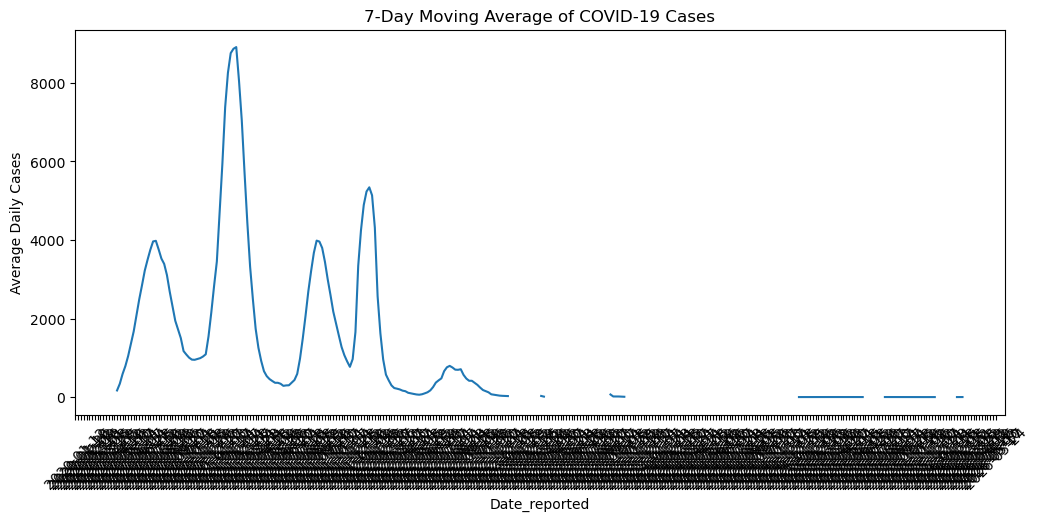

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(country_data['Date_reported'],
         country_data['7_day_average'])

plt.title("7-Day Moving Average of COVID-19 Cases")
plt.xlabel("Date_reported")
plt.ylabel("Average Daily Cases")

plt.xticks(rotation=45)

plt.show()

In [16]:
df.to_csv(r"C:\Profile\Data\covid_dashboard_data.csv", index=False)